In [1]:
# ====================================
# LightGBM Regressor 회귀 실습
# ====================================

In [3]:
# 1. import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#분석을 위한
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
#메트릭 뭐 썼어 ms 썼습니다??
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [6]:
# 2. 데이터 가져오기 ( 캘리포니아 집값 데이터)
housing = fetch_california_housing()

# 입력 변수 : features (평균소득, 방 개수 등등)   < -- 독립 변수
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 타겟 변수 : 집값 <-- 종속변수
y = pd.Series(housing.target, name='target')

print("데이터 shape : ", X.shape)

데이터 shape :  (20640, 8)


In [7]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [8]:
# 3. 데이터 전처리
print('\n [결측치 확인]')
print(X.isnull().sum())


 [결측치 확인]
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [9]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42
)

In [11]:
# 4. 모델 생성 및 학습 (LightGBM 모델)
model = LGBMRegressor(
    n_estimators=300,    # 트리 개수
    learning_rate=0.05,  # 학습율
    max_depth=-1,        # 트리 최대 깊이
    num_leaves=31,       # Leaf 개수
    subsample=0.8,       # 데이터 샘플링 비율 (과적합 방지)
    colsample_bytree=0.8, # feature 샘플링 비율 (과적합 방지)
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [20]:
# 5. 예측 수행
y_pred = model.predict(X_test)

In [21]:
# 6. 성능 평가
# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 <- 모델 설명력 ( 1에 가까울수록 좋은)
r2 = r2_score(y_test, y_pred)

# 결과 출력
print('\n [LightGBM 성능]')
print(f"mae : {mae:.4f}")
print(f"rmse : {rmse:.4f}")
print(f"R2 : {r2:.4f}")


 [LightGBM 성능]
mae : 0.2953
rmse : 0.4465
R2 : 0.8478


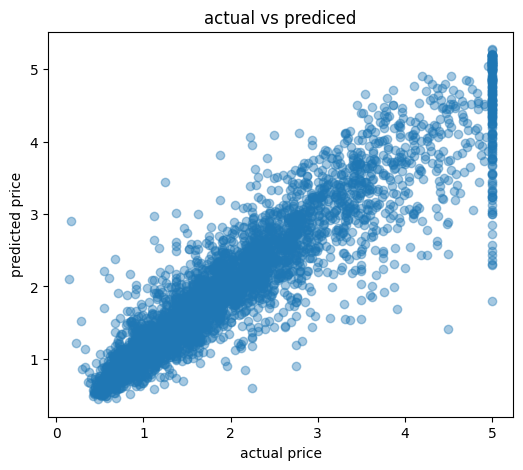

In [23]:
# 7. 성능 시각화
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual vs prediced")
plt.show()

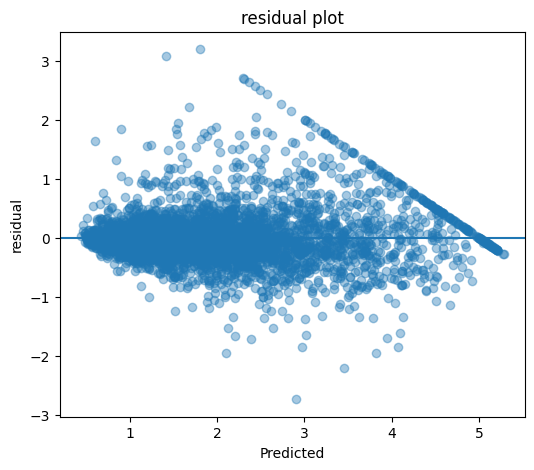

In [26]:
residuals = y_test - y_pred
plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals, alpha=0.4)

# 기준선 (오차 0)
plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("residual")

plt.title("residual plot")

plt.show()

Text(0.5, 1.0, 'Residual Distribution')

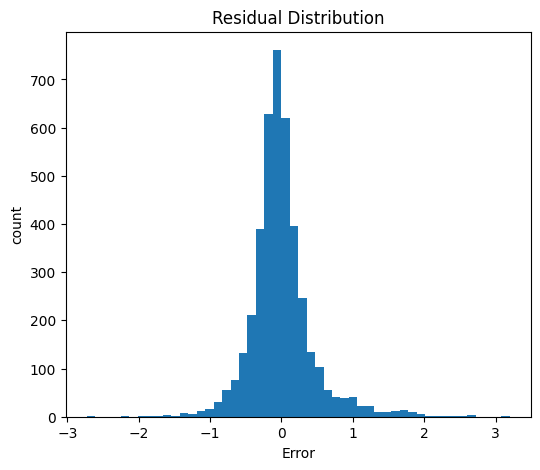

In [29]:
plt.figure(figsize=(6,5))
plt.hist(residuals,bins=50)

plt.xlabel("Error")
plt.ylabel("count")

plt.title("Residual Distribution")

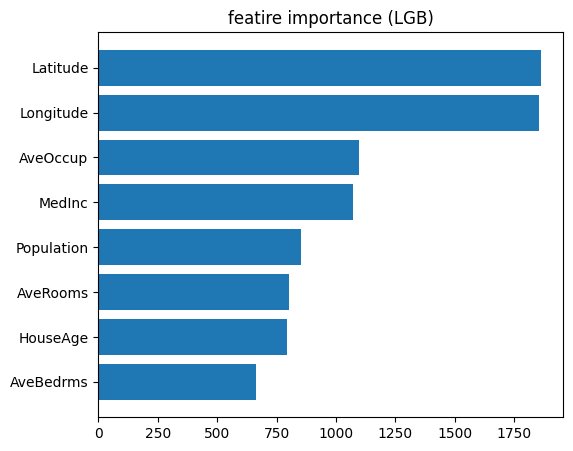

In [34]:
# 8. Feature Importance
importance = model.feature_importances_

#중요도 정렬
indices = np.argsort(importance)

plt.figure(figsize=(6,5))

# 가로 막대 그래프
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), X.columns[indices])

plt.title("featire importance (LGB)")
plt.show()

In [35]:
# 9. 모델 예측
sample_data = X_test.iloc[:5]

# 예측 수행
sample_pred = model.predict(sample_data)

print("\n [샘플 예측 결괴]")
for i, pred in enumerate(sample_pred):
    print(f"{i+1}번째 샘플 예측 집값: {pred:.4f}")

print("\n[실제값]")
print(y_test.iloc[:5].values)


 [샘플 예측 결괴]
1번째 샘플 예측 집값: 0.5710
2번째 샘플 예측 집값: 0.9476
3번째 샘플 예측 집값: 4.9757
4번째 샘플 예측 집값: 2.4497
5번째 샘플 예측 집값: 2.5212

[실제값]
[0.477   0.458   5.00001 2.186   2.78   ]


원래는 값이 이럤지만, 보다시피 튜닝이 필요할 정도로 값이 튐.
데이터를 늘렸는데도 정확도가 떨어진다
그럼 feature를 다시 선정해야함.

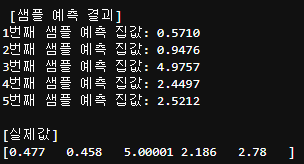

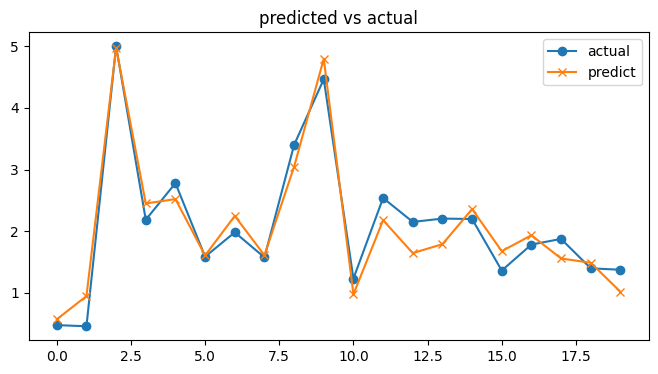

In [41]:
# 10. 예측 결과 시각화
plt.figure(figsize=(8,4))
plt.plot(y_test.iloc[:20].values, label="actual", marker='o')   #실제값
plt.plot(model.predict(X_test.iloc[:20]), label="predict", marker='x') #예측값

plt.title("predicted vs actual")
plt.legend()
plt.show()
# AI 모델로는 예측 결과 무조건 나온다.. 도메인 role 베이스랑 해서 맞춰야한다. 